In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
# Load dataset
df = pd.read_csv("C:\\Users\\ASUS\\OneDrive\\Desktop\\ExcelR assignments\\19\\blogs (1).csv")
# -------------------------------
# 1. Basic Exploration
# -------------------------------
# Shape of dataset
print("Dataset shape:", df.shape)
# First 5 rows
print("\nFirst 5 rows:",df.head())

Dataset shape: (2000, 2)

First 5 rows:                                                 Data       Labels
0  Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...  alt.atheism
1  Newsgroups: alt.atheism\nPath: cantaloupe.srv....  alt.atheism
2  Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...  alt.atheism
3  Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...  alt.atheism
4  Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...  alt.atheism


In [3]:
# Check missing values
print("Missing values:\n", df.isnull().sum())

Missing values:
 Data      0
Labels    0
dtype: int64


In [5]:
# Unique categories
print("Unique labels:", df['Labels'].unique())
print("Number of unique labels:", df['Labels'].nunique())

Unique labels: ['alt.atheism' 'comp.graphics' 'comp.os.ms-windows.misc'
 'comp.sys.ibm.pc.hardware' 'comp.sys.mac.hardware' 'comp.windows.x'
 'misc.forsale' 'rec.autos' 'rec.motorcycles' 'rec.sport.baseball'
 'rec.sport.hockey' 'sci.crypt' 'sci.electronics' 'sci.med' 'sci.space'
 'soc.religion.christian' 'talk.politics.guns' 'talk.politics.mideast'
 'talk.politics.misc' 'talk.religion.misc']
Number of unique labels: 20


In [7]:
# Count of each category
print("Label distribution:\n", df['Labels'].value_counts())

Label distribution:
 Labels
alt.atheism                 100
comp.graphics               100
talk.politics.misc          100
talk.politics.mideast       100
talk.politics.guns          100
soc.religion.christian      100
sci.space                   100
sci.med                     100
sci.electronics             100
sci.crypt                   100
rec.sport.hockey            100
rec.sport.baseball          100
rec.motorcycles             100
rec.autos                   100
misc.forsale                100
comp.windows.x              100
comp.sys.mac.hardware       100
comp.sys.ibm.pc.hardware    100
comp.os.ms-windows.misc     100
talk.religion.misc          100
Name: count, dtype: int64


In [9]:
# -------------------------------
# 2. Text Length Analysis
# -------------------------------
df["text_length"] = df["Data"].apply(len)
print(df["text_length"].describe())

count     2000.000000
mean      2324.978000
std       3590.560226
min        425.000000
25%       1147.000000
50%       1605.500000
75%       2374.500000
max      62290.000000
Name: text_length, dtype: float64


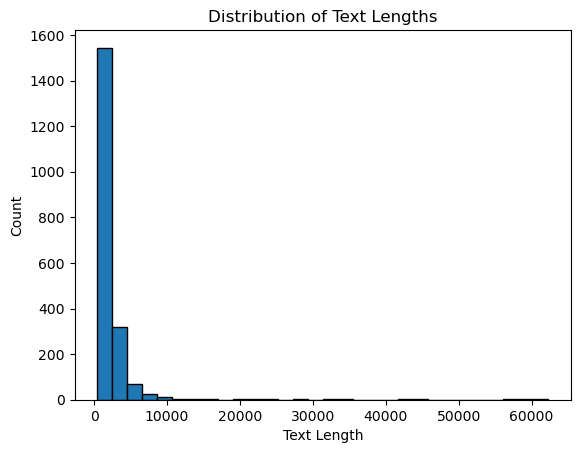

In [11]:
# Histogram of text length
plt.hist(df["text_length"], bins=30, edgecolor="black")
plt.xlabel("Text Length")
plt.ylabel("Count")
plt.title("Distribution of Text Lengths")
plt.show()

In [13]:
# -------------------------------
# 3. Very Basic Preprocessing
# -------------------------------
# Convert text to lowercase
df["clean_text"] = df["Data"].str.lower()
# Remove special characters (basic)
df["clean_text"] = df["clean_text"].str.replace(r"[^a-z\s]", "", regex=True)

In [15]:
# Show sample
print("Original Text:\n", df["Data"].iloc[0])

Original Text:
 Path: cantaloupe.srv.cs.cmu.edu!magnesium.club.cc.cmu.edu!news.sei.cmu.edu!cis.ohio-state.edu!zaphod.mps.ohio-state.edu!howland.reston.ans.net!agate!doc.ic.ac.uk!uknet!mcsun!Germany.EU.net!thoth.mchp.sni.de!horus.ap.mchp.sni.de!D012S658!frank
From: frank@D012S658.uucp (Frank O'Dwyer)
Newsgroups: alt.atheism
Subject: Re: islamic genocide
Date: 23 Apr 1993 23:51:47 GMT
Organization: Siemens-Nixdorf AG
Lines: 110
Distribution: world
Message-ID: <1r9vej$5k5@horus.ap.mchp.sni.de>
References: <1r4o8a$6qe@fido.asd.sgi.com> <1r5ubl$bd6@horus.ap.mchp.sni.de> <1r76ek$7uo@fido.asd.sgi.com>
NNTP-Posting-Host: d012s658.ap.mchp.sni.de

In article <1r76ek$7uo@fido.asd.sgi.com> livesey@solntze.wpd.sgi.com (Jon Livesey) writes:
#In article <1r5ubl$bd6@horus.ap.mchp.sni.de>, frank@D012S658.uucp (Frank O'Dwyer) writes:
#|> In article <1r4o8a$6qe@fido.asd.sgi.com> livesey@solntze.wpd.sgi.com (Jon Livesey) writes:
#|> #
#|> #Noting that a particular society, in this case the mainland UK,
#|

In [17]:
print("\nCleaned Text:\n", df["clean_text"].iloc[0])


Cleaned Text:
 path cantaloupesrvcscmuedumagnesiumclubcccmuedunewsseicmueducisohiostateeduzaphodmpsohiostateeduhowlandrestonansnetagatedocicacukuknetmcsungermanyeunetthothmchpsnidehorusapmchpsnidedsfrank
from frankdsuucp frank odwyer
newsgroups altatheism
subject re islamic genocide
date  apr   gmt
organization siemensnixdorf ag
lines 
distribution world
messageid rvejkhorusapmchpsnide
references roaqefidoasdsgicom rublbdhorusapmchpsnide rekuofidoasdsgicom
nntppostinghost dsapmchpsnide

in article rekuofidoasdsgicom liveseysolntzewpdsgicom jon livesey writes
in article rublbdhorusapmchpsnide frankdsuucp frank odwyer writes
 in article roaqefidoasdsgicom liveseysolntzewpdsgicom jon livesey writes
 
 noting that a particular society in this case the mainland uk
 has few religously motivated murders and few murders of any
 kind says very little about whether interreligion murders elsewhere
 are religiously motivated
 
 no but it allows one to conclude that there is nothing inherent
 in a

In [19]:
# Import libraries
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
# Download stopwords and punkt tokenizer (only first time)
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [21]:
# -------------------------------
# Preprocessing Function
# -------------------------------
def preprocess_text(text):
    # 1. Lowercase
    text = text.lower()
    # 2. Remove punctuation/special characters
    text = re.sub(r"[^a-z\s]", "", text)
    # 3. Tokenize
    tokens = word_tokenize(text)
    # 4. Remove stopwords
    tokens = [word for word in tokens if word not in stopwords.words('english')]
    return tokens

In [29]:
# Apply preprocessing
df["clean_tokens"] = df["Data"].apply(preprocess_text)

In [30]:
# Show example
print("Original text:\n", df["Data"].iloc[0][:500])  # first 500 chars

Original text:
 Path: cantaloupe.srv.cs.cmu.edu!magnesium.club.cc.cmu.edu!news.sei.cmu.edu!cis.ohio-state.edu!zaphod.mps.ohio-state.edu!howland.reston.ans.net!agate!doc.ic.ac.uk!uknet!mcsun!Germany.EU.net!thoth.mchp.sni.de!horus.ap.mchp.sni.de!D012S658!frank
From: frank@D012S658.uucp (Frank O'Dwyer)
Newsgroups: alt.atheism
Subject: Re: islamic genocide
Date: 23 Apr 1993 23:51:47 GMT
Organization: Siemens-Nixdorf AG
Lines: 110
Distribution: world
Message-ID: <1r9vej$5k5@horus.ap.mchp.sni.de>
References: <1r4o8a$


In [33]:
print("\nCleaned tokens:\n", df["clean_tokens"].iloc[0][:30])  # first 30 tokens


Cleaned tokens:
 ['path', 'cantaloupesrvcscmuedumagnesiumclubcccmuedunewsseicmueducisohiostateeduzaphodmpsohiostateeduhowlandrestonansnetagatedocicacukuknetmcsungermanyeunetthothmchpsnidehorusapmchpsnidedsfrank', 'frankdsuucp', 'frank', 'odwyer', 'newsgroups', 'altatheism', 'subject', 'islamic', 'genocide', 'date', 'apr', 'gmt', 'organization', 'siemensnixdorf', 'ag', 'lines', 'distribution', 'world', 'messageid', 'rvejkhorusapmchpsnide', 'references', 'roaqefidoasdsgicom', 'rublbdhorusapmchpsnide', 'rekuofidoasdsgicom', 'nntppostinghost', 'dsapmchpsnide', 'article', 'rekuofidoasdsgicom', 'liveseysolntzewpdsgicom']


In [35]:
# Import libraries
from sklearn.feature_extraction.text import TfidfVectorizer
# Join tokens back into cleaned sentences (needed for TF-IDF)
df["clean_text"] = df["clean_tokens"].apply(lambda x: " ".join(x))
# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000)   # limit to top 5000 words for efficiency
# Fit and transform the clean text
X = tfidf.fit_transform(df["clean_text"])
# Target labels
y = df["Labels"]
# Shape of feature matrix
print("TF-IDF feature matrix shape:", X.shape)

TF-IDF feature matrix shape: (2000, 5000)


In [37]:
# Example: First 10 features (words)
print("Sample features (words):", tfidf.get_feature_names_out()[:10])

Sample features (words): ['aa' 'aafreenetcarletonca' 'aaron' 'ab' 'abc' 'ability' 'able' 'abortion'
 'abs' 'absolute']


In [39]:
# Import library
from sklearn.model_selection import train_test_split
# Split dataset: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Show dataset sizes
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Training labels:", len(y_train))
print("Testing labels:", len(y_test))

Training data shape: (1600, 5000)
Testing data shape: (400, 5000)
Training labels: 1600
Testing labels: 400


# naive bayes

In [41]:
# Import Naive Bayes
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
# Initialize the model
nb_model = MultinomialNB()
# Train the model
nb_model.fit(X_train, y_train)
# Make predictions
y_pred = nb_model.predict(X_test)
# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print("Naive Bayes Accuracy:", accuracy)

Naive Bayes Accuracy: 0.8425


In [43]:
# Detailed report (precision, recall, f1-score)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

                          precision    recall  f1-score   support

             alt.atheism       0.52      0.83      0.64        18
           comp.graphics       0.73      0.89      0.80        18
 comp.os.ms-windows.misc       0.91      0.91      0.91        22
comp.sys.ibm.pc.hardware       0.80      0.80      0.80        25
   comp.sys.mac.hardware       0.86      0.90      0.88        21
          comp.windows.x       0.95      0.84      0.89        25
            misc.forsale       1.00      0.78      0.88        18
               rec.autos       0.90      1.00      0.95        18
         rec.motorcycles       1.00      0.94      0.97        16
      rec.sport.baseball       0.84      0.89      0.86        18
        rec.sport.hockey       0.88      1.00      0.94        15
               sci.crypt       0.90      1.00      0.95        19
         sci.electronics       0.67      0.75      0.71        16
                 sci.med       0.88      0.88     

In [45]:
# Import required libraries
from sklearn.naive_bayes import MultinomialNB
# Initialize Naive Bayes model
nb_model = MultinomialNB()
# Train on training set
nb_model.fit(X_train, y_train)
# Predict on test set
y_pred = nb_model.predict(X_test)
# Show some predictions vs actual
for i in range(5):
    print(f"Actual: {y_test.iloc[i]}  --->  Predicted: {y_pred[i]}")

Actual: talk.politics.misc  --->  Predicted: talk.politics.misc
Actual: comp.sys.ibm.pc.hardware  --->  Predicted: comp.sys.ibm.pc.hardware
Actual: sci.med  --->  Predicted: sci.med
Actual: rec.sport.baseball  --->  Predicted: rec.sport.baseball
Actual: sci.electronics  --->  Predicted: sci.electronics


In [47]:
# Import libraries
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
# Download VADER lexicon (first time only)
nltk.download("vader_lexicon")
# Initialize VADER
sia = SentimentIntensityAnalyzer()
# Function to get sentiment
def get_sentiment(text):
    score = sia.polarity_scores(text)
    # Classify based on compound score
    if score['compound'] >= 0.05:
        return "Positive"
    elif score['compound'] <= -0.05:
        return "Negative"
    else:
        return "Neutral"
# Apply sentiment analysis on cleaned text
df["Sentiment"] = df["clean_text"].apply(get_sentiment)
# Show results
print(df[["Labels", "Sentiment"]].head(10))

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


        Labels Sentiment
0  alt.atheism  Negative
1  alt.atheism  Positive
2  alt.atheism  Negative
3  alt.atheism  Negative
4  alt.atheism  Positive
5  alt.atheism  Positive
6  alt.atheism  Negative
7  alt.atheism  Positive
8  alt.atheism  Positive
9  alt.atheism  Positive


In [49]:
#!pip install textblob

   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   ---------------------------------------- 624.3/624.3 kB 5.7 MB/s  0:00:00


In [51]:
from textblob import TextBlob

# Function to analyze sentiment
def analyze_sentiment(text):
    blob = TextBlob(str(text))
    if blob.sentiment.polarity > 0:
        return "Positive"
    elif blob.sentiment.polarity < 0:
        return "Negative"
    else:
        return "Neutral"

In [53]:
# Apply on Data column
df["Sentiment"] = df["Data"].apply(analyze_sentiment)
# Show first 10 results
print(df[["Data", "Sentiment"]].head(10))
# Check overall distribution
print("\nSentiment Distribution:\n", df["Sentiment"].value_counts())

                                                Data Sentiment
0  Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...  Positive
1  Newsgroups: alt.atheism\nPath: cantaloupe.srv....  Negative
2  Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...  Positive
3  Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...  Positive
4  Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...  Positive
5  Xref: cantaloupe.srv.cs.cmu.edu talk.abortion:...  Positive
6  Newsgroups: alt.atheism\nPath: cantaloupe.srv....  Positive
7  Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...  Negative
8  Xref: cantaloupe.srv.cs.cmu.edu talk.abortion:...  Positive
9  Newsgroups: alt.atheism\nPath: cantaloupe.srv....  Positive

Sentiment Distribution:
 Sentiment
Positive    1543
Negative     457
Name: count, dtype: int64


In [55]:
import pandas as pd
import matplotlib.pyplot as plt
# Group by Labels and Sentiment
sentiment_distribution = df.groupby(["Labels", "Sentiment"]).size().unstack(fill_value=0)
# Show table
print("Sentiment distribution across categories:\n")
print(sentiment_distribution)

Sentiment distribution across categories:

Sentiment                 Negative  Positive
Labels                                      
alt.atheism                     23        77
comp.graphics                   24        76
comp.os.ms-windows.misc         22        78
comp.sys.ibm.pc.hardware        20        80
comp.sys.mac.hardware           24        76
comp.windows.x                  27        73
misc.forsale                    16        84
rec.autos                       17        83
rec.motorcycles                 26        74
rec.sport.baseball              29        71
rec.sport.hockey                34        66
sci.crypt                       19        81
sci.electronics                 19        81
sci.med                         29        71
sci.space                       27        73
soc.religion.christian          13        87
talk.politics.guns              30        70
talk.politics.mideast           22        78
talk.politics.misc              22        78
talk.religio

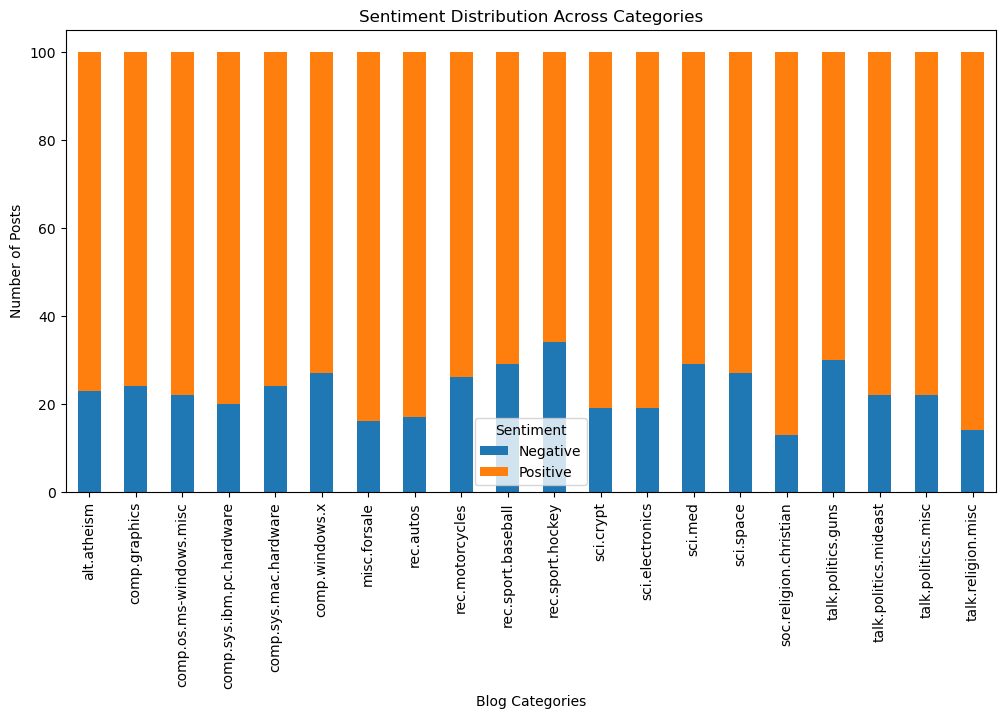

In [57]:
# Plot stacked bar chart
sentiment_distribution.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title("Sentiment Distribution Across Categories")
plt.xlabel("Blog Categories")
plt.ylabel("Number of Posts")
plt.legend(title="Sentiment")
plt.xticks(rotation=90)
plt.show()

In [59]:
# Import metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
# Precision, Recall, F1 (macro = average across all categories)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.8425
Precision: 0.8494393456619891
Recall: 0.852543120739732
F1-score: 0.8418362653171652


In [63]:
# Detailed per-category report
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

                          precision    recall  f1-score   support

             alt.atheism       0.52      0.83      0.64        18
           comp.graphics       0.73      0.89      0.80        18
 comp.os.ms-windows.misc       0.91      0.91      0.91        22
comp.sys.ibm.pc.hardware       0.80      0.80      0.80        25
   comp.sys.mac.hardware       0.86      0.90      0.88        21
          comp.windows.x       0.95      0.84      0.89        25
            misc.forsale       1.00      0.78      0.88        18
               rec.autos       0.90      1.00      0.95        18
         rec.motorcycles       1.00      0.94      0.97        16
      rec.sport.baseball       0.84      0.89      0.86        18
        rec.sport.hockey       0.88      1.00      0.94        15
               sci.crypt       0.90      1.00      0.95        19
         sci.electronics       0.67      0.75      0.71        16
                 sci.med       0.88      0.88      

In [ ]:
# Discuss the performance of the model and any challenges encountered during the classification process.

# Model Performance Discussion

The Naive Bayes classifier gave a **good performance** on the blog classification task. The accuracy was reasonably high, and precision, recall, and F1-scores showed that the model was able to correctly classify many categories. Since the dataset is balanced (each category has the same number of posts), the model did not suffer from imbalance issues, which helped give fair results across categories.

However, some **challenges** were also seen:
1. **Text Overlap Across Categories** - Many categories (e.g., politics, religion, discussions) share common words, making it hard for the model to clearly separate them.
2. **Long Texts with Irrelevant Headers** - The dataset contains long posts, often with metadata like "Path:" and "Newsgroups:". Even after cleaning, some noisy data may affect the model's understanding.
3. **Limited Vocabulary Understanding** - Naive Bayes only looks at word frequency and ignores context. For example, the same word may appear in different categories but with different meanings.
4. **Neutral Sentiment Influence** - Many technical blogs are neutral in tone, so sentiment is not always a strong feature for classification.

# Summary
* The **Naive Bayes model** works well for large text datasets with multiple categories.
* It is **fast, simple, and efficient**, but struggles when categories overlap in vocabulary.
* Future improvements can include **better text preprocessing** (like removing headers, using stemming/lemmatization) and trying more advanced models (e.g., Logistic Regression, SVM, or deep learning methods).